In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from src.constants import STATE_CONFIG
from src.datasources import glofas, grrr
from src.utils.rp_calc import calculate_one_group_rp

load_dotenv()

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
STATE = "Benue"
cfg = STATE_CONFIG[STATE]

ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]
WET_MONTHS = [8, 9, 10, 11]  # Aug–Nov
RP_LEVELS = [3, 4, 5]
FIGURES_DIR = "figures"

## Load data

In [3]:
# GloFAS reanalysis
df_gf = glofas.load_glofas_reanalysis(cfg["glofas_station"])

# Google GRRR reanalysis
ds_grrr = grrr.load_reanalysis(gauge=cfg["google_gauge"])
df_grrr = grrr.process_reanalysis(ds_grrr)

# Floodscan pixel-level parquet
df_fs_pixels = stratus.load_parquet_from_blob(cfg["floodscan_blob"])

I0527 15:11:30.907359 4720251 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0527 15:11:30.920137 4720266 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(102, generation: 1)


## Floodscan flood years

Flood year classification uses all-months annual max mean SFED across pixels — no wet-season filter
before the annual max, consistent with notebook 08. RP thresholds derived empirically via the
Weibull-based `calculate_one_group_rp` function.

In [4]:
df_fs_daily = (
    df_fs_pixels.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "sfed_mean"})
)
df_fs_daily["date"] = pd.to_datetime(df_fs_daily["date"])
df_fs_daily = df_fs_daily[
    df_fs_daily["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

df_fs_annual = (
    df_fs_daily.assign(year=df_fs_daily["date"].dt.year)
    .groupby("year")["sfed_mean"]
    .max()
    .reset_index()
)
df_fs_annual = calculate_one_group_rp(df_fs_annual, col_name="sfed_mean", ascending=False)

fs_rp_thresholds = {
    rp: df_fs_annual["sfed_mean"].quantile(1 - 1 / rp)
    for rp in RP_LEVELS
}
fs_event_years = {
    rp: set(df_fs_annual[df_fs_annual["sfed_mean"] > fs_rp_thresholds[rp]]["year"])
    for rp in RP_LEVELS
}

for rp in RP_LEVELS:
    print(f"Floodscan {rp}-yr RP threshold: {fs_rp_thresholds[rp]:.4f}  →  event years: {sorted(fs_event_years[rp])}")

Floodscan 3-yr RP threshold: 0.0916  →  event years: [1998, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
Floodscan 4-yr RP threshold: 0.0998  →  event years: [1998, 2012, 2014, 2015, 2016, 2019, 2022]
Floodscan 5-yr RP threshold: 0.1100  →  event years: [2012, 2014, 2015, 2019, 2022]


## Model wet-season annual maxima

Aug–Nov annual max discharge for GloFAS (Makurdi) and Google GRRR (Makurdi HYBAS gauge),
restricted to the common year range. The inner join ensures both models have data for every
year used in the grid search.

In [5]:
df_gf["time"] = pd.to_datetime(df_gf["time"])
df_gf_annual = (
    df_gf[df_gf["time"].dt.month.isin(WET_MONTHS)]
    .assign(year=lambda x: x["time"].dt.year)
    .groupby("year")["dis24"]
    .max()
    .reset_index()
)
df_gf_annual = df_gf_annual[
    df_gf_annual["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

df_grrr["valid_time"] = pd.to_datetime(df_grrr["valid_time"])
df_grrr_annual = (
    df_grrr[df_grrr["valid_time"].dt.month.isin(WET_MONTHS)]
    .assign(year=lambda x: x["valid_time"].dt.year)
    .groupby("year")["streamflow"]
    .max()
    .reset_index()
)
df_grrr_annual = df_grrr_annual[
    df_grrr_annual["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

combined = (
    df_gf_annual.set_index("year")[["dis24"]]
    .join(df_grrr_annual.set_index("year")[["streamflow"]], how="inner")
    .dropna()
)

N = len(combined)
eval_years = set(combined.index)
print(f"Common years for grid search: {N}  ({combined.index.min()}–{combined.index.max()})")
print()
print(combined.sort_values("dis24", ascending=False).head(10).to_string())

Common years for grid search: 26  (1998–2023)

             dis24   streamflow
year                           
2012  23116.296875  3659.010010
2022  15466.359375  3961.586182
2007  14470.328125  2968.380859
2002  13569.828125  2484.624756
2001  13124.890625  3085.906250
2008  12944.781250  3088.405762
2003  12878.140625  2741.500732
2014  12821.000000  3067.105713
1999  12812.750000  3272.876709
1998  12595.046875  2643.333008


## Grid search over threshold combinations

Iterate over all (GloFAS rank, Google rank) pairs where:
- **rank 0**: model never triggers (threshold = ∞)
- **rank k**: the k years with highest discharge trigger (threshold = minimum of top-k values)

A year **activates** if GloFAS OR Google exceeds its respective threshold.  
Metrics evaluated against Floodscan 3/4/5-year RP event years.

In [6]:
gf_sorted = combined["dis24"].sort_values(ascending=False).values
gr_sorted = combined["streamflow"].sort_values(ascending=False).values


def get_threshold(sorted_vals, rank):
    """Discharge threshold for a given rank. rank 0 → never trigger (inf)."""
    if rank == 0:
        return np.inf
    return float(sorted_vals[rank - 1])


records = {rp: [] for rp in RP_LEVELS}

for n_gf in range(N + 1):
    gf_thresh_i = get_threshold(gf_sorted, n_gf)
    for n_gr in range(N + 1):
        gr_thresh_i = get_threshold(gr_sorted, n_gr)

        activated = {
            y for y in eval_years
            if (combined.loc[y, "dis24"] > gf_thresh_i)
            or (combined.loc[y, "streamflow"] > gr_thresh_i)
        }

        for rp in RP_LEVELS:
            events = fs_event_years[rp] & eval_years
            non_events = eval_years - events

            tp = len(activated & events)
            fp = len(activated & non_events)
            fn = len(events - activated)
            tn = len(non_events - activated)

            precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            f1 = (
                2 * precision * recall / (precision + recall)
                if (not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0)
                else np.nan
            )

            records[rp].append({
                "n_gf": n_gf,
                "n_gr": n_gr,
                "gf_thresh": gf_thresh_i if np.isfinite(gf_thresh_i) else np.nan,
                "gr_thresh": gr_thresh_i if np.isfinite(gr_thresh_i) else np.nan,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "accuracy": (tp + tn) / N,
            })

grid = {rp: pd.DataFrame(v) for rp, v in records.items()}

print("Grid search complete.")
for rp in RP_LEVELS:
    best = (
        grid[rp]
        .dropna(subset=["f1"])
        .nlargest(5, "f1")[["n_gf", "n_gr", "gf_thresh", "gr_thresh", "tp", "fp", "fn", "precision", "recall", "f1"]]
    )
    print(f"\n--- {rp}-yr RP  top-5 by F1 ---")
    print(best.to_string(index=False))

Grid search complete.

--- 3-yr RP  top-5 by F1 ---
 n_gf  n_gr    gf_thresh   gr_thresh  tp  fp  fn  precision   recall   f1
    0    17          NaN 2496.658691   7   9   2     0.4375 0.777778 0.56
    1    17 23116.296875 2496.658691   7   9   2     0.4375 0.777778 0.56
    2    17 15466.359375 2496.658691   7   9   2     0.4375 0.777778 0.56
    3    17 14470.328125 2496.658691   7   9   2     0.4375 0.777778 0.56
    4    17 13569.828125 2496.658691   7   9   2     0.4375 0.777778 0.56

--- 4-yr RP  top-5 by F1 ---
 n_gf  n_gr    gf_thresh   gr_thresh  tp  fp  fn  precision   recall       f1
    0     4          NaN 3272.876709   3   0   4   1.000000 0.428571 0.600000
    1     4 23116.296875 3272.876709   3   0   4   1.000000 0.428571 0.600000
    2     4 15466.359375 3272.876709   3   0   4   1.000000 0.428571 0.600000
    3     4 14470.328125 3272.876709   3   0   4   1.000000 0.428571 0.600000
    0     8          NaN 2968.380859   4   3   3   0.571429 0.571429 0.571429

--- 5

## Performance heatmaps

POD (recall), Precision, and F1 for the OR trigger evaluated against each Floodscan RP level.
X-axis = number of Google GRRR years triggered, Y-axis = number of GloFAS years triggered.

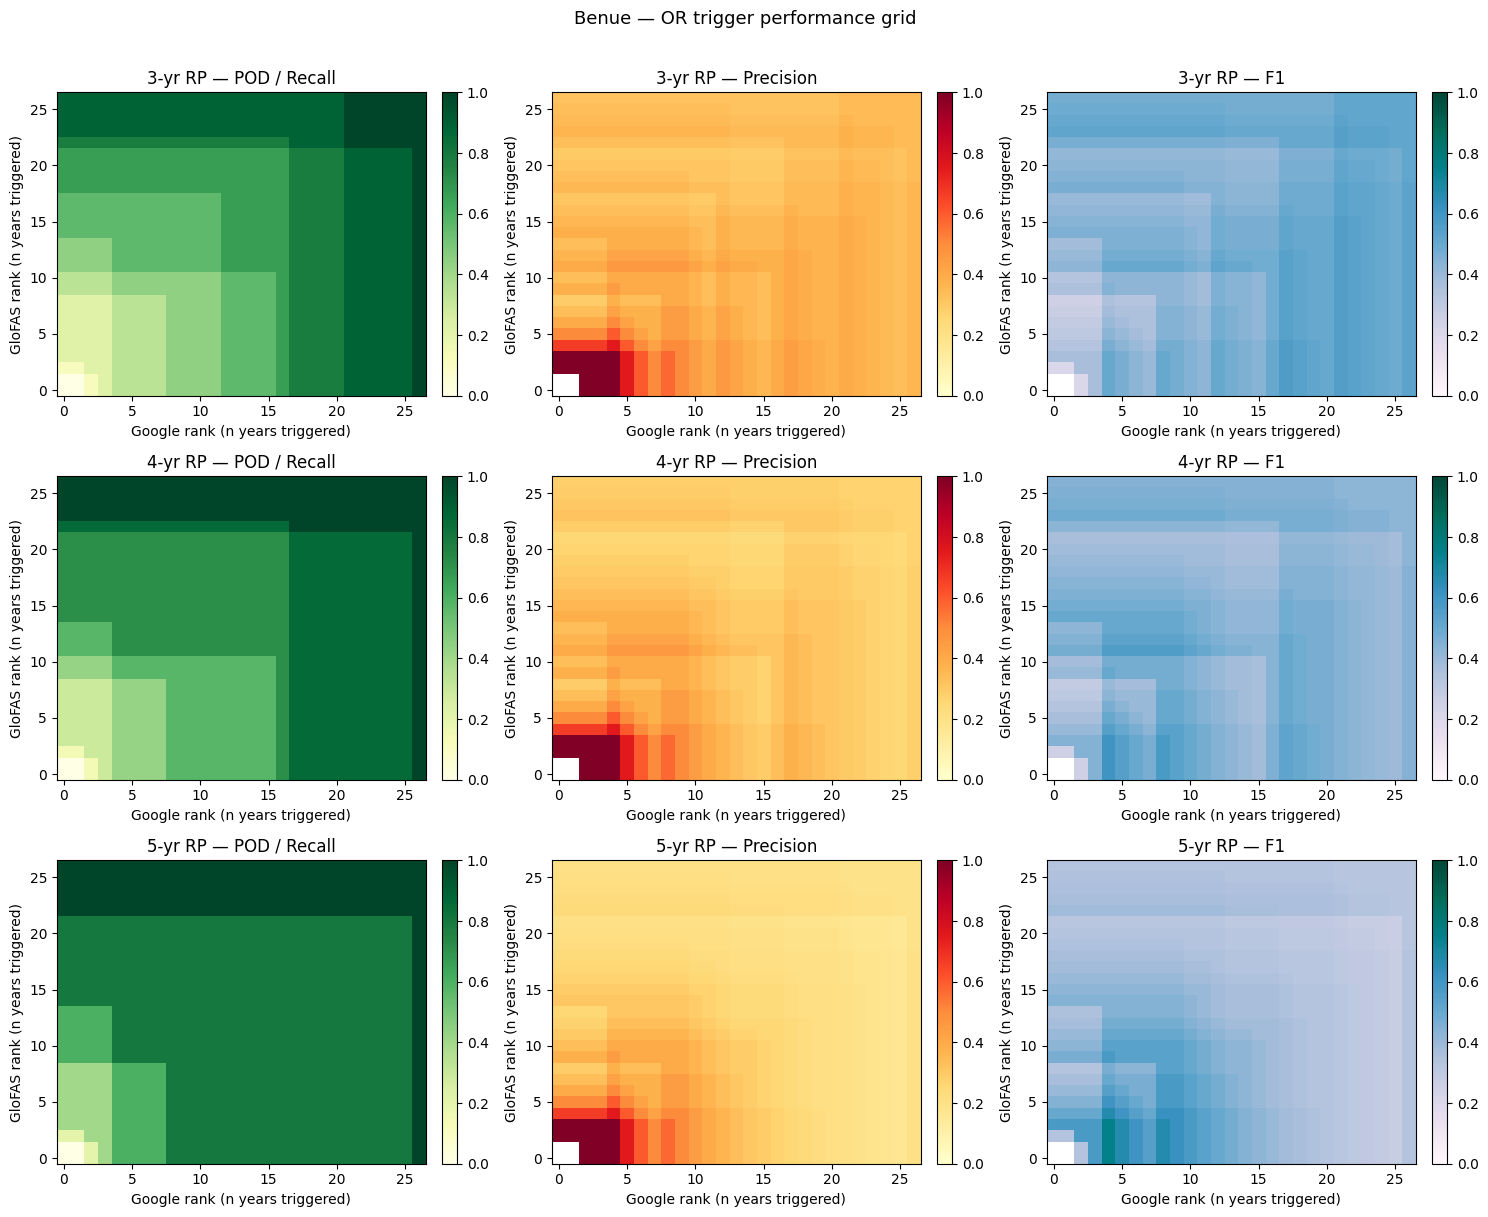

In [7]:
METRICS = [("recall", "POD / Recall", "YlGn"), ("precision", "Precision", "YlOrRd"), ("f1", "F1", "PuBuGn")]

fig, axes = plt.subplots(len(RP_LEVELS), 3, figsize=(15, 4 * len(RP_LEVELS)))

for row_i, rp in enumerate(RP_LEVELS):
    df = grid[rp]
    for col_i, (metric, label, cmap) in enumerate(METRICS):
        ax = axes[row_i, col_i]
        pivot = df.pivot(index="n_gf", columns="n_gr", values=metric).values.astype(float)
        im = ax.imshow(pivot, vmin=0, vmax=1, cmap=cmap, aspect="auto", origin="lower")
        ax.set_title(f"{rp}-yr RP — {label}")
        ax.set_xlabel("Google rank (n years triggered)")
        ax.set_ylabel("GloFAS rank (n years triggered)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"{STATE} — OR trigger performance grid", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(
    f"{FIGURES_DIR}/{STATE.lower()}_threshold_grid_heatmaps.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## Implied combined RP

How often does the OR trigger fire in the historical record?  
Implied RP = N / n_activations — shows the combined trigger frequency independent of Floodscan.

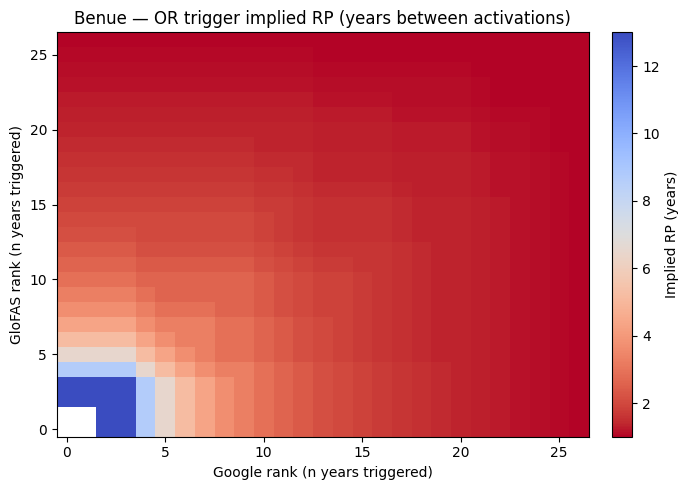

In [8]:
df_rp = grid[RP_LEVELS[0]].copy()
df_rp["n_activated"] = df_rp["tp"] + df_rp["fp"]
df_rp["implied_rp"] = N / df_rp["n_activated"].replace(0, np.nan)

pivot_rp = df_rp.pivot(index="n_gf", columns="n_gr", values="implied_rp").values.astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot_rp, cmap="coolwarm_r", aspect="auto", origin="lower", vmin=1, vmax=N / 2)
ax.set_title(f"{STATE} — OR trigger implied RP (years between activations)")
ax.set_xlabel("Google rank (n years triggered)")
ax.set_ylabel("GloFAS rank (n years triggered)")
plt.colorbar(im, ax=ax, label="Implied RP (years)", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(
    f"{FIGURES_DIR}/{STATE.lower()}_threshold_implied_rp.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## Threshold selection

Set `SELECTED_GF_RANK` and `SELECTED_GOOGLE_RANK` after reviewing the heatmaps above.  
The cell prints the corresponding m³/s thresholds and which years activate.

In [9]:
# ── Set these after reviewing the heatmaps ──────────────────────
SELECTED_GF_RANK = 5     # top-N GloFAS years trigger
SELECTED_GOOGLE_RANK = 5  # top-N Google years trigger
# ────────────────────────────────────────────────────────────────

gf_thresh_selected = get_threshold(gf_sorted, SELECTED_GF_RANK)
gr_thresh_selected = get_threshold(gr_sorted, SELECTED_GOOGLE_RANK)

print(f"GloFAS threshold  (rank {SELECTED_GF_RANK} / {N} years): {gf_thresh_selected:,.0f} m³/s")
print(f"Google threshold  (rank {SELECTED_GOOGLE_RANK} / {N} years): {gr_thresh_selected:,.0f} m³/s")
print(f"Implied GloFAS RP: {N / SELECTED_GF_RANK:.1f} yr  |  Google RP: {N / SELECTED_GOOGLE_RANK:.1f} yr")
print()

activated_selected = {
    y for y in eval_years
    if (combined.loc[y, "dis24"] > gf_thresh_selected)
    or (combined.loc[y, "streamflow"] > gr_thresh_selected)
}
print(f"Activated years ({len(activated_selected)}): {sorted(activated_selected)}")
print()
for rp in RP_LEVELS:
    events = fs_event_years[rp] & eval_years
    print(f"Floodscan {rp}-yr RP events ({len(events)}): {sorted(events)}")

GloFAS threshold  (rank 5 / 26 years): 13,125 m³/s
Google threshold  (rank 5 / 26 years): 3,088 m³/s
Implied GloFAS RP: 5.2 yr  |  Google RP: 5.2 yr

Activated years (6): [1999, 2002, 2007, 2012, 2019, 2022]

Floodscan 3-yr RP events (9): [1998, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2022]
Floodscan 4-yr RP events (7): [1998, 2012, 2014, 2015, 2016, 2019, 2022]
Floodscan 5-yr RP events (5): [2012, 2014, 2015, 2019, 2022]


## Year-by-year evaluation

In [10]:
df_yr = combined.copy()
df_yr["gf_trigger"] = (df_yr["dis24"] > gf_thresh_selected).astype(int)
df_yr["gr_trigger"] = (df_yr["streamflow"] > gr_thresh_selected).astype(int)
df_yr["or_trigger"] = ((df_yr["gf_trigger"] == 1) | (df_yr["gr_trigger"] == 1)).astype(int)

for rp in RP_LEVELS:
    events = fs_event_years[rp] & eval_years
    df_yr[f"fs_{rp}yr"] = df_yr.index.isin(events).astype(int)

display_cols = (
    ["dis24", "streamflow", "gf_trigger", "gr_trigger", "or_trigger"]
    + [f"fs_{rp}yr" for rp in RP_LEVELS]
)
df_yr[display_cols].sort_index(ascending=False)

,dis24,streamflow,gf_trigger,gr_trigger,or_trigger,fs_3yr,fs_4yr,fs_5yr
year,,,,,,,,
2023,11668.804688,2487.429199,0,0,0,0,0,0
2022,15466.359375,3961.586182,1,1,1,1,1,1
2021,10429.929688,2006.320312,0,0,0,0,0,0
2020,12343.710938,2721.678711,0,0,0,0,0,0
2019,11030.640625,3589.425049,0,1,1,1,1,1
2018,10507.500000,2869.592041,0,0,0,1,0,0
2017,7476.507812,2446.681152,0,0,0,1,0,0
2016,9503.648438,2599.993164,0,0,0,1,1,0
2015,10009.257812,2146.977051,0,0,0,1,1,1


## Performance summary at selected thresholds

In [11]:
def prf_detail(activated, events, non_events, n_total):
    tp = len(activated & events)
    fp = len(activated & non_events)
    fn = len(events - activated)
    tn = len(non_events - activated)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if (not np.isnan(precision) and not np.isnan(recall) and (precision + recall) > 0)
        else np.nan
    )
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": round(precision, 2),
        "Recall (POD)": round(recall, 2),
        "F1": round(f1, 2),
        "Accuracy": round((tp + tn) / n_total, 2),
    }


summary_rows = {}
for rp in RP_LEVELS:
    events = fs_event_years[rp] & eval_years
    non_events = eval_years - events
    summary_rows[f"Floodscan {rp}-yr RP"] = prf_detail(activated_selected, events, non_events, N)

pd.DataFrame(summary_rows).T

,TP,FP,FN,TN,Precision,Recall (POD),F1,Accuracy
Floodscan 3-yr RP,3.0,3.0,6.0,14.0,0.5,0.33,0.40,0.65
Floodscan 4-yr RP,3.0,3.0,4.0,16.0,0.5,0.43,0.46,0.73
Floodscan 5-yr RP,3.0,3.0,2.0,18.0,0.5,0.60,0.55,0.81
